# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [4]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [5]:
data = pd.read_csv("./data/cleaned_aviation_data.csv")
data

,Aircraft.damage,Make,Model,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Weather.Condition,Broad.phase.of.flight,Publication.Date,is_destroyed
0,Destroyed,PIPER,PA24-180,1.0,4.0,0.0,UNK,other,1996-09-19,True
1,Destroyed,CESSNA,172M,1.0,3.0,0.0,IMC,Cruise,2007-02-26,True
2,Destroyed,ROCKWELL,112,1.0,2.0,0.0,IMC,Cruise,2000-09-12,True
3,Destroyed,CESSNA,180,1.0,4.0,0.0,IMC,other,2001-11-06,True
4,Destroyed,BELLANCA,17-30A,1.0,0.0,0.0,IMC,Cruise,1983-01-02,True
...,...,...,...,...,...,...,...,...,...,...
53532,Unknown,CESSNA,172F,NaN,0.0,1.0,NaN,NaN,2022-12-22,False
53533,Unknown,AIR TRACTOR,AT502,NaN,1.0,0.0,NaN,NaN,2022-12-28,False
53534,Unknown,PIPER,PA-28-151,NaN,0.0,1.0,NaN,NaN,2022-12-29,False
53535,Substantial,AMERICAN CHAMPION AIRCRAFT,8GCBC,1.0,0.0,0.0,VMC,NaN,2022-12-27,False


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [7]:
# data["Number.of.Engines"].value_counts()
data['Aircraft.size'] = np.where(data['Number.of.Engines'] > 2, 'large', 'small')
data

,Aircraft.damage,Make,Model,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Weather.Condition,Broad.phase.of.flight,Publication.Date,is_destroyed,Aircraft.size
0,Destroyed,PIPER,PA24-180,1.0,4.0,0.0,UNK,other,1996-09-19,True,small
1,Destroyed,CESSNA,172M,1.0,3.0,0.0,IMC,Cruise,2007-02-26,True,small
2,Destroyed,ROCKWELL,112,1.0,2.0,0.0,IMC,Cruise,2000-09-12,True,small
3,Destroyed,CESSNA,180,1.0,4.0,0.0,IMC,other,2001-11-06,True,small
4,Destroyed,BELLANCA,17-30A,1.0,0.0,0.0,IMC,Cruise,1983-01-02,True,small
...,...,...,...,...,...,...,...,...,...,...,...
53532,Unknown,CESSNA,172F,NaN,0.0,1.0,NaN,NaN,2022-12-22,False,small
53533,Unknown,AIR TRACTOR,AT502,NaN,1.0,0.0,NaN,NaN,2022-12-28,False,small
53534,Unknown,PIPER,PA-28-151,NaN,0.0,1.0,NaN,NaN,2022-12-29,False,small
53535,Substantial,AMERICAN CHAMPION AIRCRAFT,8GCBC,1.0,0.0,0.0,VMC,NaN,2022-12-27,False,small


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

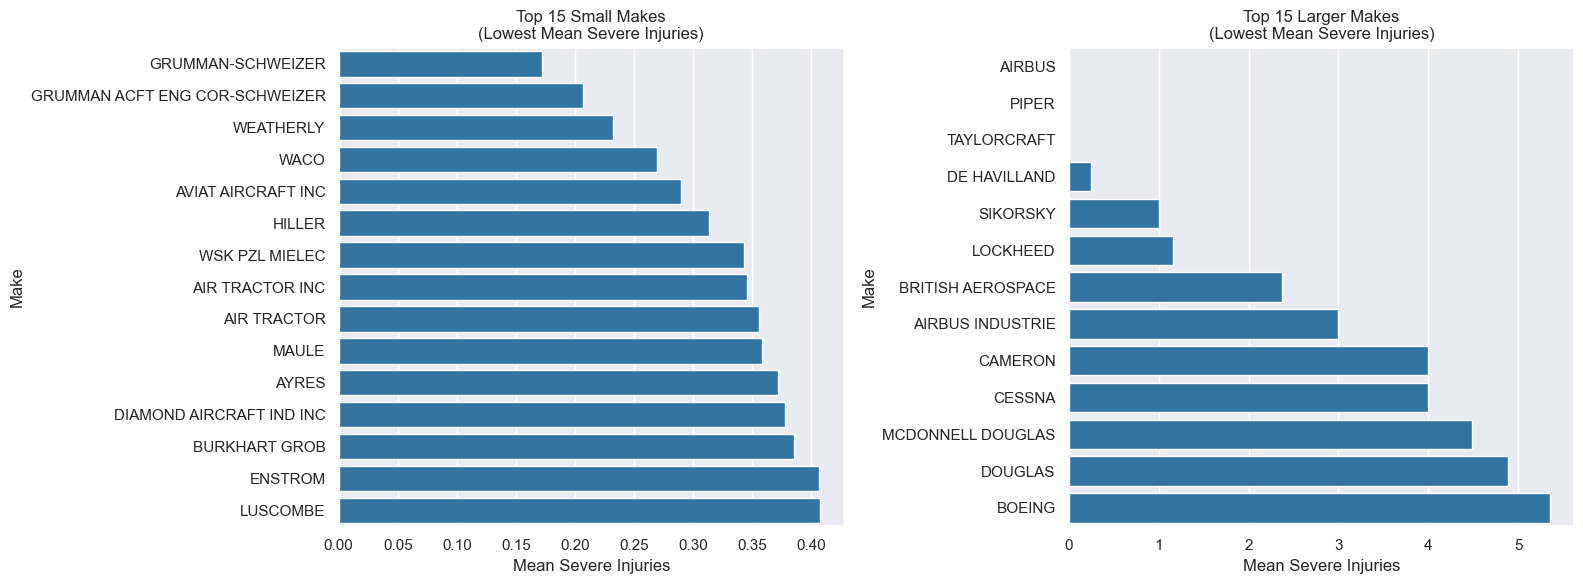

In [12]:
# Ensure that NaNs are filled
data['Total.Fatal.Injuries'] = data['Total.Fatal.Injuries'].fillna(0.0)
data['Total.Serious.Injuries'] = data['Total.Serious.Injuries'].fillna(0.0)
# Create a new injuries column
data['Severe_Injuries'] = data['Total.Fatal.Injuries'] + data['Total.Serious.Injuries']

# Get the small and large aircrafts
small_aircraft = data[data['Aircraft.size'] == 'small']
large_aircraft = data[data['Aircraft.size'] == 'large']

# Calculate the mean severe injuries per Make and grab the lowest 15
top_15_small = small_aircraft.groupby('Make')['Severe_Injuries'].mean().nsmallest(15).reset_index()
top_15_large = large_aircraft.groupby('Make')['Severe_Injuries'].mean().nsmallest(15).reset_index()

# Add a group identifier label to keep things organized for Seaborn
top_15_small['Group'] = 'Small Makes'
top_15_large['Group'] = 'Larger Makes'

# Combine them into a single clean plotting DataFrame
combined_df = pd.concat([top_15_small, top_15_large])

# LET'S PLOT:
sns.set_context("notebook")
sns.set_style("darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)

# Plot Small Makes on the left canvas
sns.barplot(
    data=top_15_small, 
    y='Make', 
    x='Severe_Injuries', 
    ax=axes[0], 
)
axes[0].set(title="Top 15 Small Makes\n(Lowest Mean Severe Injuries)", xlabel="Mean Severe Injuries")

# Plot Large Makes on the right canvas
sns.barplot(
    data=top_15_large, 
    y='Make', 
    x='Severe_Injuries', 
    ax=axes[1], 
)
axes[1].set(title="Top 15 Larger Makes\n(Lowest Mean Severe Injuries)", xlabel="Mean Severe Injuries")

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.